In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
cols = ['engine_id', 'cycle'] + \
       [f'op{i}' for i in range(1,4)] + \
       [f's{i}' for i in range(1,22)]

df = pd.read_csv('../data/raw/train_FD001.txt', sep=' ', header=None)

df = df.dropna(axis=1)

df.columns = cols

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/train_FD001.txt'

In [ ]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op1        20631 non-null  float64
 3   op2        20631 non-null  float64
 4   op3        20631 non-null  float64
 5   s1         20631 non-null  float64
 6   s2         20631 non-null  float64
 7   s3         20631 non-null  float64
 8   s4         20631 non-null  float64
 9   s5         20631 non-null  float64
 10  s6         20631 non-null  float64
 11  s7         20631 non-null  float64
 12  s8         20631 non-null  float64
 13  s9         20631 non-null  float64
 14  s10        20631 non-null  float64
 15  s11        20631 non-null  float64
 16  s12        20631 non-null  float64
 17  s13        20631 non-null  float64
 18  s14        20631 non-null  float64
 19  s15        20631 non-null  float64
 20  s16        20631 

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [ ]:
df.shape

(20631, 26)

In [ ]:
df['engine_id'].nunique()

100

In [ ]:
df.groupby('engine_id')['cycle'].max()

engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [ ]:
max_cycle = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

df = df.merge(max_cycle, on='engine_id')

df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

In [ ]:
df[df['engine_id'] == 1][['cycle', 'RUL']].head()


,cycle,RUL
0,1,191
1,2,190
2,3,189
3,4,188
4,5,187


In [ ]:
df[df['engine_id'] == 1][['cycle', 'RUL']].tail()

,cycle,RUL
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


<Axes: xlabel='cycle'>

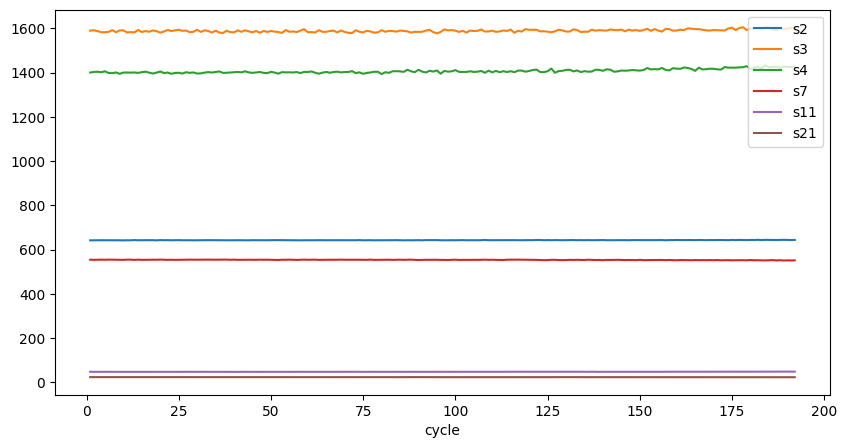

In [ ]:
engine_1 = df[df['engine_id'] == 1]

engine_1.plot(
    x='cycle',
    y=['s2', 's3', 's4', 's7', 's11', 's21'],
    figsize=(10,5)
)

In [ ]:
df.var().sort_values()

s1           0.000000e+00
op3          0.000000e+00
s10          0.000000e+00
s18          0.000000e+00
s19          0.000000e+00
s16          1.203765e-35
s5           2.840037e-29
op2          8.588541e-08
s6           1.929279e-06
op1          4.784340e-06
s15          1.406628e-03
s8           5.038938e-03
s13          5.172330e-03
s21          1.171825e-02
s20          3.266927e-02
s11          7.133568e-02
s2           2.500533e-01
s12          5.439850e-01
s7           7.833883e-01
s17          2.398667e+00
s3           3.759099e+01
s4           8.101089e+01
s14          3.639005e+02
s9           4.876536e+02
engine_id    8.542545e+02
RUL          4.744591e+03
cycle        4.744591e+03
dtype: float64

In [ ]:
drop_cols = ['s1', 'op3', 's10', 's18', 's19', 's16', 's5', 'op2', 's6', 'op1']
df = df.drop(columns=drop_cols)
sensor_cols = [col for col in df.columns if col.startswith('s')]

In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(engine_1[sensor_cols])

scaled_df = pd.DataFrame(scaled, columns=sensor_cols)
scaled_df['cycle'] = engine_1['cycle'].values

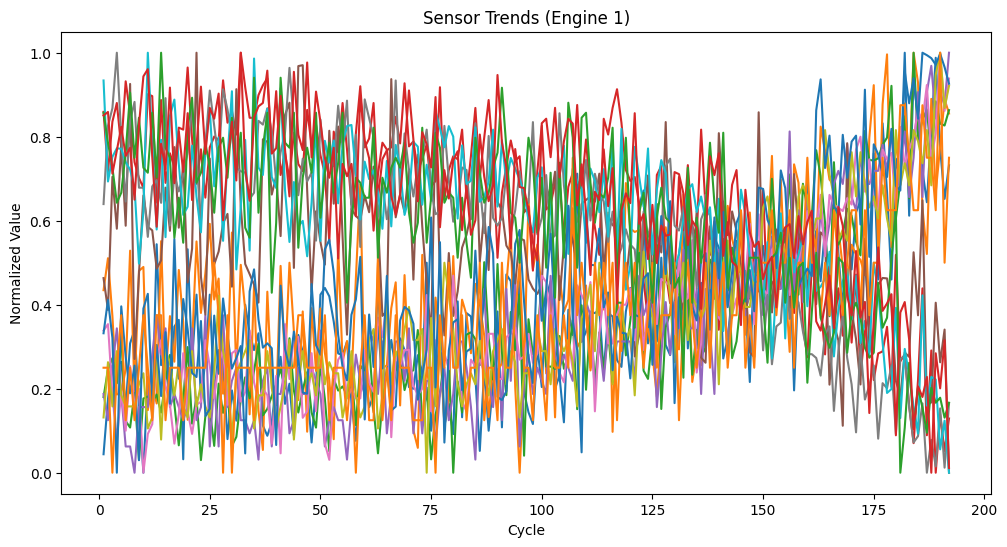

In [ ]:
plt.figure(figsize=(12,6))
for col in sensor_cols:
    plt.plot(scaled_df['cycle'], scaled_df[col])

plt.xlabel("Cycle")
plt.ylabel("Normalized Value")
plt.title("Sensor Trends (Engine 1)")
plt.show()

<Axes: xlabel='cycle'>

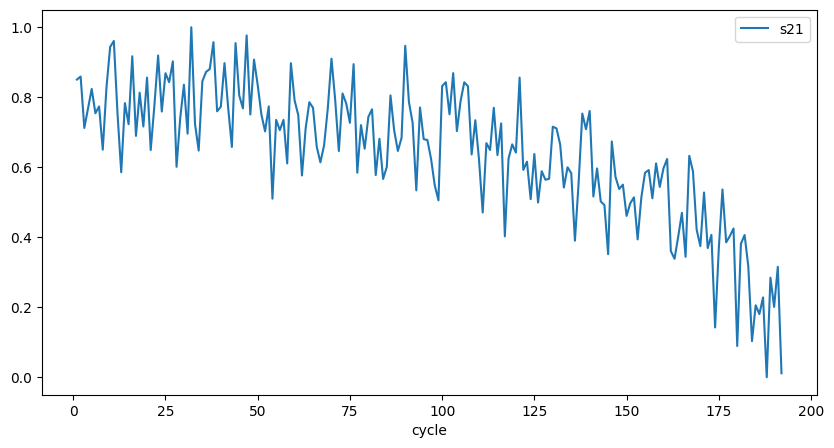

In [ ]:
selected = ['s21']

scaled_df.plot(x='cycle', y=selected, figsize=(10,5))